In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


<p style="line-height:50px;text-align:center;"><span style="font-family:Georgia;font-size:36px;color:#D8BFD8;font-style:normal;font-weight:bold;"> Modeling for Unbalanced Datasets: <br><span style="font-family:Cursive;font-size:58px;color:#4B0082;font-style:italic;font-weight:normal;">
Tips and Strategies</span>
</span>
</p>

---

When dealing with unbalanced datasets in machine learning, it's important to approach the problem carefully. Unbalanced datasets can occur when one class or group of data points dominates the other classes. This can cause issues when training machine learning models, because the model may be overly biased towards the dominant class. 

---
Here are some tips and strategies for dealing with unbalanced datasets:

1. Collect more data: The more data you have, the less impact unbalanced classes will have on your model. This will give your model a more balanced view of the data, and may help it make more accurate predictions.
2. Use oversampling and undersampling: These techniques involve adjusting the number of data points in each class to make the classes more balanced. With oversampling, you can add more data points to the minority class, and with undersampling, you can remove data points from the majority class.
3. Use class weights: Many machine learning algorithms have the option to specify class weights. This allows you to tell the algorithm to give more importance to the minority class when making predictions. This can help to balance out the bias towards the dominant class.
4. Use a different evaluation metric: The standard metric for evaluating machine learning models, accuracy, may not be the best metric to use when dealing with unbalanced datasets. Instead, you can use metrics like precision, recall, and F1 score, which take into account false positives and false negatives.
5. Use a different algorithm: Some algorithms are better suited to dealing with unbalanced datasets than others. For example, decision trees and random forests can handle unbalanced data well, because they can learn from both the majority and minority classes. Other algorithms, like support vector machines, may not be as effective.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report,f1_score,recall_score,roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc,rcParams
import itertools

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

In [3]:
# Reading the dataset
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Number of variables and observations in the data set
print("Number of observations: " ,len(df))
print("Number of variables: ", len(df.columns))

Number of observations:  284807
Number of variables:  31


In [5]:
# We want to observe the types of variables in the dataset and whether they contain null values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

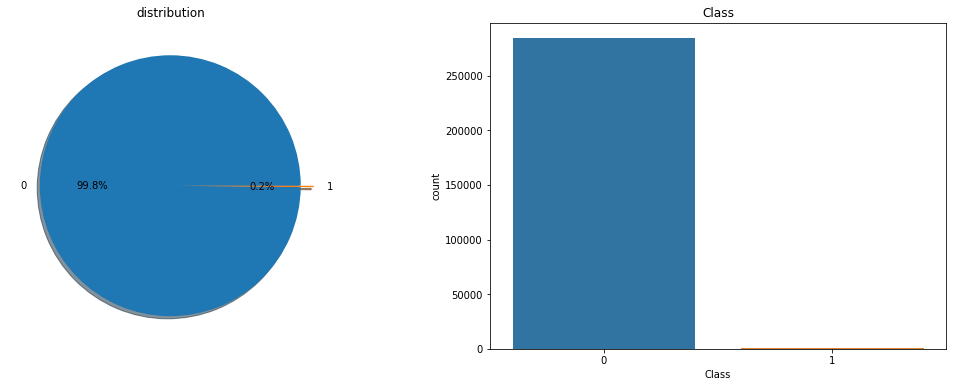

In [6]:
f,ax=plt.subplots(1,2,figsize=(18,6))
df['Class'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('distribution')
ax[0].set_ylabel('')
sns.countplot('Class',data=df,ax=ax[1])
ax[1].set_title('Class')
plt.show()

In [7]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


In [8]:
# Standardizing Time and Amount variables
rob_scaler = RobustScaler()
df['Amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0


In [9]:
# We apply the hold out method and divide the data set into training and testing (80%, 20%).
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [10]:
# defining and training the model and its success score
model = LogisticRegression(random_state=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f"%(accuracy))

Accuracy: 0.999


</p>
<p style="border:5px solid #DA70D6;">Accuracy is the ratio of correct predictions to all predictions in the system. The accuracy score of the model we created is 0.999. We can say that our model works perfectly, right? Let's take a look at the Confusion Matrix to examine its performance.</p>
</p>

## Confusion Matrix

The Confusion Matrix is a table used to describe the performance of a classification model's true values on test data. It contains 4 different combinations of estimated and actual values.

**Terminology and derivations from a confusion matrix**
* condition positive (P): the number of real positive cases in the data
* condition negative (N): the number of real negative cases in the data
* true positive (TP): A test result that correctly indicates the presence of a condition or characteristic
* true negative (TN): A test result that correctly indicates the absence of a condition or characteristic
* false positive (FP): A test result which wrongly indicates that a particular condition or attribute is present
* false negative (FN): A test result which wrongly indicates that a particular condition or attribute is absent

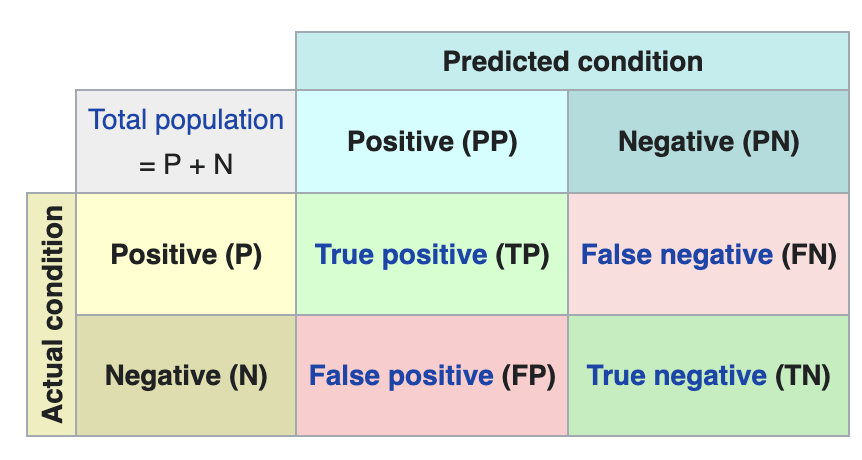

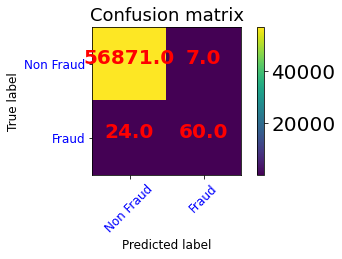

In [11]:
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.viridis):

    plt.rcParams.update({'font.size': 20})
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title,fontdict={'size':'18'})
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45,fontsize=12,color="blue")
    plt.yticks(tick_marks, classes,fontsize=12,color="blue")
    rc('font', weight='bold')
    fmt = '.1f'
    thresh = cm.max()
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="red")

    plt.ylabel('True label',fontdict={'size':'12'})
    plt.xlabel('Predicted label',fontdict={'size':'12'})
    plt.tight_layout()

plot_confusion_matrix(confusion_matrix(y_test, y_pred=y_pred), classes=['Non Fraud','Fraud'],
                      title='Confusion matrix')

• A total of 56875 predictions were made for the Non Fraud class, with 56870 (TP) correct and 5 (FP) incorrect.

• A total of 87 predictions were made for the Fraud class, with 31 (FN) incorrect and 56 (TN) correct.

The model tells us that it can predict the Fraud state with 0.99 accuracies. But when we examine the confusion Matrix, the rate of false predictions in the Fraud class is quite high. While it is good at predicting the majority class, it is not good at predicting the minority class. In other words, the model correctly predicts the non-fraud class with a rate of 0.99.
The fact that the number of observations belonging to the Non-Fraud class is higher than the number of observations of the fraud class causes the model to be successful in estimating the Non-Fraud class.
With this observation we have made, we can say that the accuracy score is not a good performance measure for classification models, especially if it contains imbalances like the data set we have.
We've looked at the dataset, we can look at how we can deal with the imbalance and build a model, what methods can be applied, and with what metrics we can measure its performance.

# 1. Choosing the Right Metric

<p style="border-width:2px;border-style:solid;border-color:#DA70D6;">When dealing with imbalanced datasets, it is important to choose the right metric to evaluate the performance of the model. Traditional metrics, such as accuracy, precision, and recall, may not be appropriate for imbalanced datasets because they do not take into account the distribution of the classes in the data.</p>
<p style="border:2px solid #DA70D6;">One metric that is often used for imbalanced datasets is the F1 score. The F1 score is the harmonic mean of precision and recall, and it provides a balance between the two metrics. It is calculated as follows:</p>
</p>
<p style="border:5px solid #DA70D6;">F1 = 2 * (precision * recall) / (precision + recall)</p>
</p>
<p style="border:2px solid #DA70D6;">
Another metric that is often used for imbalanced datasets is the area under the receiver operating characteristic curve (AUC-ROC). The AUC-ROC is a measure of the model's ability to distinguish between positive and negative classes. It is calculated by plotting the true positive rate (TPR) against the false positive rate (FPR) at different classification thresholds. AUC-ROC values range from 0.5 (random guessing) to 1.0 (perfect classification).</p>

In [12]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       0.90      0.71      0.79        84

    accuracy                           1.00     56962
   macro avg       0.95      0.86      0.90     56962
weighted avg       1.00      1.00      1.00     56962



**Let's examine the Precision measure for each class.**

Returns how many of the predictions made for the 0 (non-fraud) class are correct. Looking at the confusion matrix, 56870 + 31 = 56901 non-fraud class predictions were made and 56870 of them were estimated correctly. The precision value for class 0 is 1 (56870 / 56901)

Returns how many of the predictions for the 1 (fraud) class are correct. Looking at the confusion matrix, 5 + 56 = 61 fraud class predictions were made and 56 of them were correctly estimated. The precision for class 0 is 0.92 (56 / 61)

 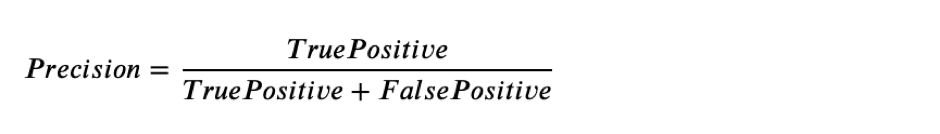

**Let's examine the Recall measure for each class.**

It shows how many of the values we need to predict for the 0(non-fraud) class are correctly predicted. We have 56870 + 5 = 56875 observations belonging to the non-fraud class and 56870 of them have been estimated correctly. The recall value for class 0 is 56870 / 56875 = 1.

It shows how many of the values we need to predict for the 1(fraud) class correctly. 31 + 56 = We have observations of 87 fraud classes and 56 of them are correctly estimated. The recall value for class 1 is 56 / 87 = 0.64.
 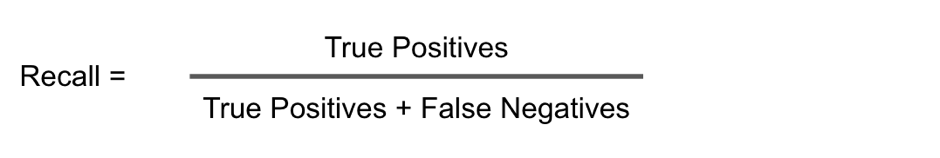
When we look at the Recall values, we can easily see the failure of estimating 1 class.

**F1-score** also expresses the harmonic mean of the recall and precision values.
 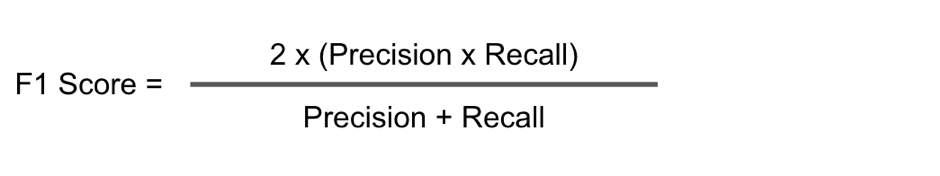

**Support** refers to the number of actual values of the classes. We can show the structural weaknesses of the measurements, that is, we can say that the imbalance in the number of observations between the classes affects the measurements.

## ROC curve

<p style="border:2px solid #DA70D6;">
A receiver operating characteristic (ROC) curve is a graphical plot that shows the performance of a binary classification model at all classification thresholds. The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at different classification thresholds. The true positive rate is the proportion of positive samples that are correctly classified as positive. It is calculated as the number of true positives divided by the number of actual positives. The false positive rate is the proportion of negative samples that are incorrectly classified as positive. It is calculated as the number of false positives divided by the number of actual negatives. </p>

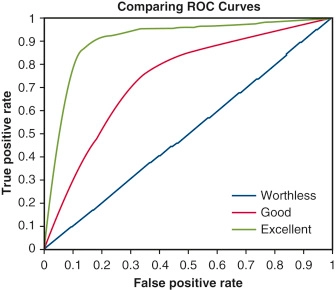

## AUC (Area under the ROC curve)

AUC stands for "Area under the ROC Curve." That is, AUC measures the entire two-dimensional area underneath the entire ROC curve (think integral calculus) from (0,0) to (1,1).
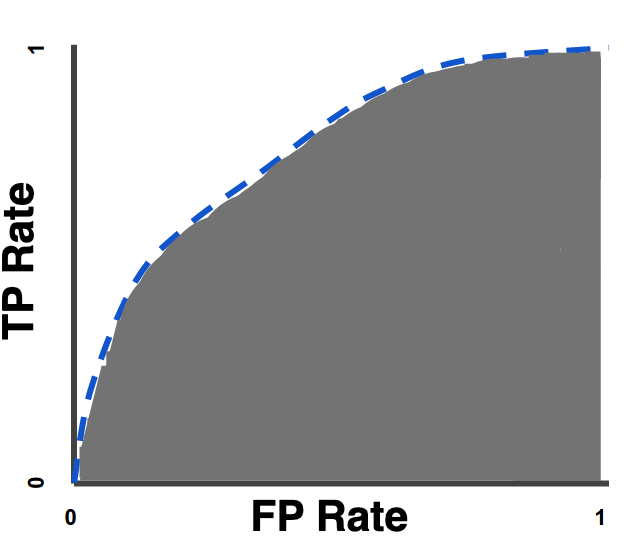

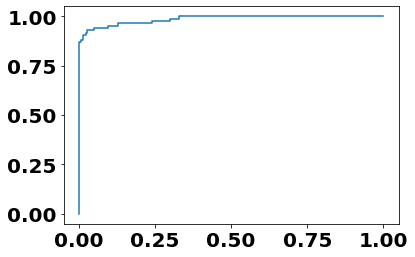

In [13]:
# Auc Roc Curve
def generate_auc_roc_curve(clf, X_test):
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test,  y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr,tpr)
    plt.show()
    pass

generate_auc_roc_curve(model, X_test)

In [14]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC ROC Curve with Area Under the curve = %.3f"%auc)

AUC ROC Curve with Area Under the curve = 0.985


<p style="border:5px solid #DA70D6;">NOTE: The methods should be applied to the training set. Correct evaluation cannot be made if it is applied to the test set.</p>

## 2. Resampling

Resampling is to make the data set more balanced by adding new samples to the minority class or removing samples from the majority class.
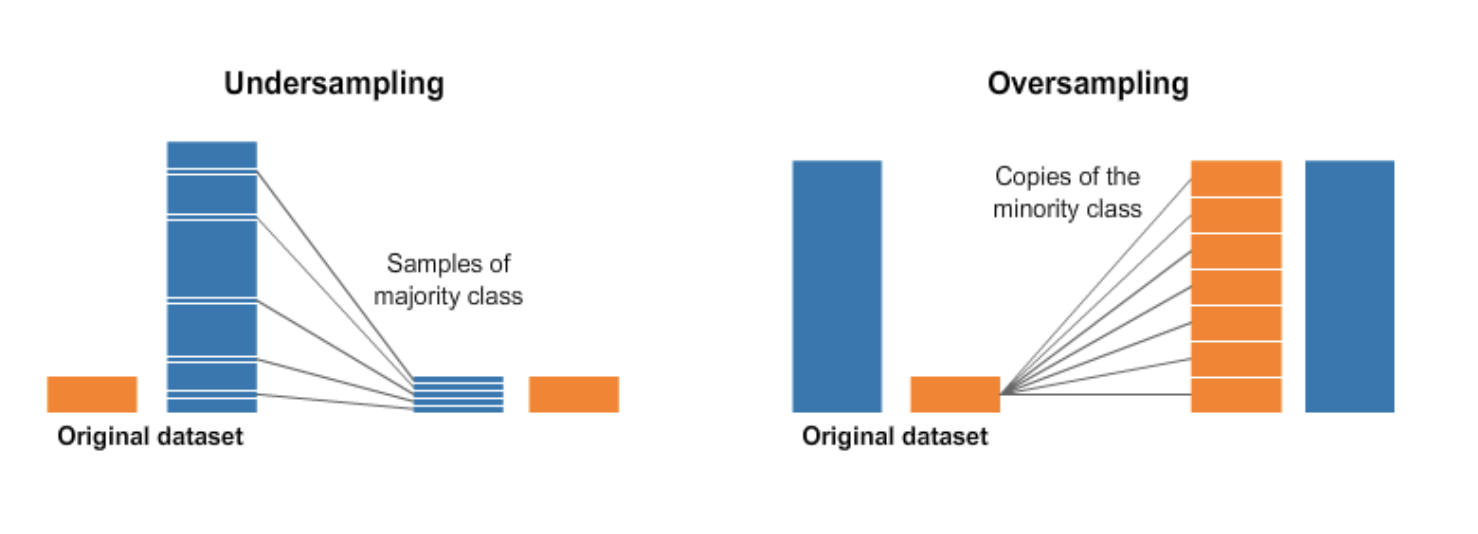

### 2.1. Oversampling

Stabilizes the dataset by duplicating minority-class samples.

#### 2.1.1. Random Oversampling:

It is the balancing of the data set by adding randomly selected samples from the minority class.
This technique can be used if your dataset is small.
It may cause overfitting.
The RandomOverSampler method takes the sampling_strategy argument, and when sampling_stratefy='minority' is called, it increments the number of the minority class to equal the number of the majority class.

We can enter a float value in this argument. For example, let the number of our minority class be 1000 and the number of the majority class be 100. If we say sampling_stratefy = 0.5, the minority class will be added to be 500.

In [15]:
# Number of classes in the training set before random oversampling
y_train.value_counts()

0    227437
1       408
Name: Class, dtype: int64

In [16]:
# Implementing RandomOver Sampling (Applying to the training set)
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')
X_randomover, y_randomover = oversample.fit_resample(X_train, y_train)

In [17]:
# Number of classes of the training set after random oversampling
y_randomover.value_counts()

0    227437
1    227437
Name: Class, dtype: int64

In [18]:
# training the model and its success rate
model.fit(X_randomover, y_randomover)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.977%


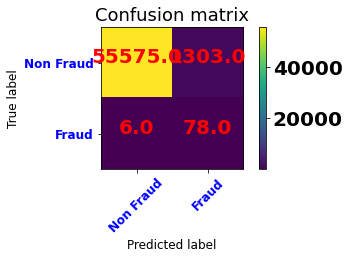

In [19]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred=y_pred), classes=['Non Fraud','Fraud'],
                      title='Confusion matrix')

In [20]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56878
           1       0.06      0.93      0.11        84

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



After applying Random Oversampling, the accuracy value of the trained model is 0.97, a decrease is observed. Looking at the Confusion Matrix and Classification report, the predicted fraud classes seem to have a high false rate, which lowered the precision of 1 class. But there is also an increase in the recall value of the 1 class, the rate of correctly estimating the fraud class of the model has increased. According to the first model, the prediction success of the Non fraud class has decreased, but the increase in the correct estimation of the fraud class is a big factor in our preference for the model created after randomoversampling.

#### 2.1.2. SMOTE Oversampling:

Generating minority class synthetic samples to prevent overfitting.

First, a random sample from the minority class is selected.
Then, k nearest neighbors are found for this sample.
One of the k nearest neighbors is randomly selected and the synthetic sample is formed by combining it with the randomly selected sample from the minority class and forming a line segment in the feature space.

In [21]:
# Number of classes in the training set before smote
y_train.value_counts()

0    227437
1       408
Name: Class, dtype: int64

In [22]:
# Applying Smote (Applying to the training set)
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X_smote, y_smote = oversample.fit_resample(X_train, y_train)

In [23]:
# class number of training set after smote
y_smote.value_counts()

0    227437
1    227437
Name: Class, dtype: int64

In [24]:
# training the model and its success rate
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.975%


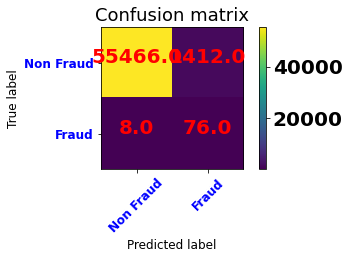

In [25]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred=y_pred), classes=['Non Fraud','Fraud'],
                      title='Confusion matrix')

Confusion matrix:
 [[55466  1412]
 [    8    76]]


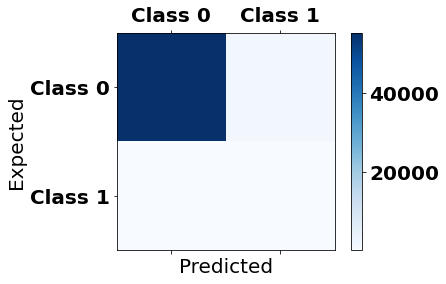

In [26]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print('Confusion matrix:\n', conf_mat)

labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

In [27]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56878
           1       0.05      0.90      0.10        84

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.98      0.99     56962



### 2.2. Undersampling

It is a technique of balancing the data set by removing samples belonging to the majority class. It can be used when you have a large data set. Since the data set we have is not large, efficient results will not be obtained. But I will explain the methods and show how some of them can be applied.

#### 2.2.1. Random Undersampling:

* Extracted samples are randomly selected.
* You can use this technique if you have a large data set.
* Information may be lost due to random selection.

In [28]:
# Number of classes in the training set before random undersampling
y_train.value_counts()

0    227437
1       408
Name: Class, dtype: int64

In [29]:
from imblearn.under_sampling import RandomUnderSampler
# transform the dataset
ranUnSample = RandomUnderSampler()
X_ranUnSample, y_ranUnSample = ranUnSample.fit_resample(X_train, y_train)

In [30]:
# After Random undersampling
y_ranUnSample.value_counts()

0    408
1    408
Name: Class, dtype: int64

# 3. Change the algorithm

In [31]:
from sklearn.ensemble import RandomForestClassifier
# train model
rfc = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)

# predict on test set
rfc_pred = rfc.predict(X_test)

accuracy_score(y_test, rfc_pred)

0.9996313331694814

In [32]:
# f1 score
f1_score(y_test, rfc_pred)

0.8645161290322582

In [33]:
# confusion matrix
pd.DataFrame(confusion_matrix(y_test, rfc_pred))

,0,1
0,56874,4
1,17,67


In [34]:
# recall score
recall_score(y_test, rfc_pred)

0.7976190476190477

## References 

1. https://imbalanced-learn.org/stable/introduction.html
2. https://courses.miuul.com/p/machine-learning
3. https://imbalanced-learn.org/dev/references/over_sampling.html